### Value at Risk
Value at Risk represent the amout of portfolio that could be lost with a certain confidence level due to random stock price movements in a given period of time

We can investigate VaR for an asset with a time window of one year

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

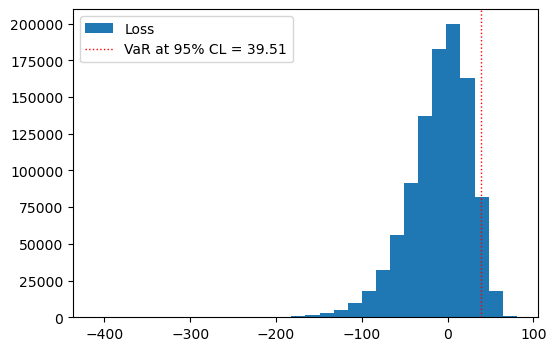

In [46]:
m = 0.12
sigma = 0.3
r = 0.08
S0 = 100
t = 1

S_risk_free = S0 * np.exp(r * t)

# Samples from distribution of stock price at t
mean_kt = m * t 
var_kt  = sigma**2 * t
St = S0 * np.exp(np.random.normal(loc=mean_kt, scale=np.sqrt(var_kt), size=1000000))

# Theoretical pdf of stock price distribution at t
mean_St = S0 * np.exp(m * t + 0.5 * sigma**2 * t)
var_St  = (S0 * np.exp(m * t + 0.5 * sigma**2 * t))**2 * (np.exp(sigma**2 * t) - 1)
Ss = np.linspace(0, 400, 2500)
log_mean = np.log(mean_St)
log_std = np.sqrt(var_kt)
lognorm = scipy.stats.lognorm.pdf(Ss, s=log_std, loc=0, scale=np.exp(log_mean))

# Define loss
Loss = S_risk_free - St
VaR  = np.percentile(Loss, 95) 

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(Loss, bins=30, label='Loss')
ax.axvline(VaR, lw=1, ls=':', color='red', label=f'VaR at 95% CL = {round(VaR, 2)}')
ax.legend()
plt.show()